# Post-Training Quantization Experiments for PyTorch CNN Classifier

This notebook contains experiments on **Dynamic Post-Training Quantization** and **Static Post-Training Quantization** applied to a PyTorch CNN classifier model trained on a fruits ripeness dataset.

We evaluate three configurations on CPU/GPU and compare them based on:
1. **Accuracy** on the test set.
2. **Average CPU Latency** per image inference.
3. **Model binary footprint (Size)** in MB.
4. **VRAM Usage** (where applicable).


## 1. Setup and Environment Configuration

First, we install all necessary libraries for model evaluation, metrics computation, and visualization.


In [1]:
!pip install torch torchvision torchaudio pytorch_lightning onnx wandb torchmetrics mlxtend seaborn matplotlib numpy pandas -qq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.8 MB/s eta 0:00:00


### Library Imports
We import the common modules for model training, dataset handling, PyTorch Lightning, quantization tools, and plotting.


In [2]:
import os
import time
import random
import zipfile
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
import wandb
from torchmetrics import Accuracy, Precision, F1Score, ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from torch.quantization import get_default_qconfig, quantize_jit, fuse_modules, prepare, convert
from torch.ao.quantization import QConfigMapping


### Path and Metadata Settings
Configure storage paths for checkpoints and constants like the number of classes and batch size.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

RAW_ROOT = "/content/drive/MyDrive/DataLake/01_raw"
PROCESSED_ROOT = "/content/drive/MyDrive/DataLake/02_processed"
ARTIFACTS_ROOT = "/content/drive/MyDrive/DataLake/03_artifacts"
PTH_PATH = os.path.join(ARTIFACTS_ROOT, "models/deep_perm_net1.pth")

NUM_CLASSES = 4
BATCH_SIZE = 64


Mounted at /content/drive


### Dataset and DataLoader Definitions
Define `FruitClassificationDataset` class and helper functions to build training, validation, and test loaders.


In [4]:
def create_sequence_indices(num_samples, seq_len):
    indices = []
    for i in range(num_samples):
        seq = [i]
        if num_samples > 1:
            remaining_indices = [j for j in range(num_samples) if j != i]
            if len(remaining_indices) >= seq_len - 1:
                seq.extend(random.sample(remaining_indices, seq_len - 1))
            else:
                seq.extend(random.choices(remaining_indices, k=seq_len - 1))
        elif seq_len > 1:
            seq.extend([i] * (seq_len - 1))
    indices.append(seq)
    return indices

class FruitClassificationDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform or transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders(raw_dir, batch_size=32):
    def get_split(split):
        files = glob.glob(os.path.join(raw_dir, split, "**/*.jpg"), recursive=True)
        labels = []
        for f in files:
            p = os.path.basename(os.path.dirname(f)).lower()
            labels.append(0 if 'unripe' in p else 2 if 'overripe' in p or 'overipe' in p else 3 if 'rotten' in p else 1)
        ds = FruitClassificationDataset(files, labels)
        return files, DataLoader(ds, batch_size=batch_size, shuffle=(split=='train'),
                                 num_workers=os.cpu_count() // 2,
                                 pin_memory=True,
                                 persistent_workers=True,
                                 prefetch_factor=4)
    _, train_dl = get_split('train')
    _, val_dl = get_split('valid')
    test_files, test_dl = get_split('test')
    return train_dl, val_dl, test_dl, test_files

train_dl, val_dl, test_dl, test_files = get_dataloaders(RAW_ROOT, BATCH_SIZE)


### Model Architecture Definition
Declare the full structure of `FruitClassifierModel` class.


In [5]:
class FruitClassifierModel(pl.LightningModule):
    def __init__(self, pth_path=None, num_classes=4, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.num_classes = num_classes

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten()
        )

        if pth_path and os.path.exists(pth_path):
            full_state_dict = torch.load(pth_path, map_location="cpu").get("state_dict", torch.load(pth_path, map_location="cpu"))
            feature_extractor_state_dict = {}
            for k, v in full_state_dict.items():
                if k.startswith("feature_extractor."):
                    feature_extractor_state_dict[k.replace("feature_extractor.", "")] = v
                elif k.startswith("model.feature_extractor."):
                    feature_extractor_state_dict[k.replace("model.feature_extractor.", "")] = v
            if feature_extractor_state_dict:
                try:
                    self.feature_extractor.load_state_dict(feature_extractor_state_dict, strict=True)
                    print(f"Loaded feature_extractor backbone from {pth_path}")
                except Exception as e:
                    print(f"Warning: Could not load feature_extractor weights: {e}. Non-strict load.")
                    self.feature_extractor.load_state_dict(feature_extractor_state_dict, strict=False)
            else:
                print(f"Warning: No feature_extractor weights found in {pth_path}.")

        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        self.classification_head = nn.Linear(2048, self.num_classes)

    def forward(self, x):
        feats = self.feature_extractor(x)
        logits = self.classification_head(feats)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log_dict({"train_loss": loss, "train_acc": acc}, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.classification_head.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


## 2. Load Trained Model

We instantiate the FP32 model and load the pretrained weight dictionary from `fruit_classifier.pth`.


In [6]:
print(f"Loading model from: {PTH_PATH}")
model_fp32 = FruitClassifierModel(pth_path=None, num_classes=NUM_CLASSES, lr=0.0)
state_dict = torch.load(os.path.join(ARTIFACTS_ROOT, "models", "fruit_classifier.pth"), map_location=torch.device('cpu'))

new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('model.'):
        new_state_dict[k[len('model.'):]] = v
    else:
        new_state_dict[k] = v

model_fp32.load_state_dict(new_state_dict, strict=True)
model_fp32.eval()
print("FP32 model loaded successfully.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_fp32.to(device)
print(f"Model moved to {device}")


Loading model from: /content/drive/MyDrive/DataLake/03_artifacts/models/deep_perm_net1.pth
FP32 model loaded successfully.
Model moved to cpu


## 3. Helper Functions for Benchmarking

We define helper functions to calculate the binary model footprint size (in MB) and evaluate accuracy, CPU latency, and peak memory overhead.


In [7]:
def calculate_model_size(model):
    torch.save(model.state_dict(), "temp_model.p")
    size_mb = os.path.getsize("temp_model.p") / (1024*1024)
    os.remove("temp_model.p")
    return size_mb

def benchmark_model(model, dataloader, device, description="Model"):
    model.eval()
    model.to(device)

    acc_metric = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)
    confmat_metric = ConfusionMatrix(task="multiclass", num_classes=NUM_CLASSES).to(device)

    total_time, total_samples = 0.0, 0
    peak_vram_before = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            start_time = time.perf_counter()
            outputs = model(inputs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            total_time += (end_time - start_time)
            total_samples += inputs.size(0)
            preds = outputs.argmax(dim=-1)
            acc_metric.update(preds, targets)
            confmat_metric.update(preds, targets)

    avg_latency = (total_time / total_samples) * 1000 if total_samples > 0 else 0
    peak_vram_after = torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0
    peak_vram = (peak_vram_after - peak_vram_before) / (1024 * 1024) if torch.cuda.is_available() else 0
    accuracy = acc_metric.compute().item()
    confusion_matrix = confmat_metric.compute().cpu().numpy()
    model_size = calculate_model_size(model)

    results = {
        "Description": description,
        "Accuracy": accuracy,
        "Latency (ms/img)": avg_latency,
        "Model Size (MB)": model_size,
        "Peak VRAM (MB)": peak_vram if torch.cuda.is_available() else 'N/A'
    }
    print(f"\n--- {description} Benchmark ---")
    for k, v in results.items():
        print(f"{k}: {v:.4f}" if isinstance(v, (float, np.float32)) else f"{k}: {v}")
    return results, confusion_matrix


## 4. FP32 Baseline Benchmark

Establish the baseline performance metrics using the original floating-point model.


In [8]:
print("Benchmarking FP32 model...")
fp32_results, fp32_conf_matrix = benchmark_model(model_fp32, test_dl, device, description="FP32 Model")


Benchmarking FP32 model...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- FP32 Model Benchmark ---
Description: FP32 Model
Accuracy: 0.9164
Latency (ms/img): 6.9206
Model Size (MB): 0.9545
Peak VRAM (MB): N/A


## 5. Dynamic Quantization Benchmark

Dynamic Post-Training Quantization quantizes weights to 8-bit integers while keeping activations in floating-point during storage. During execution, activations are dynamically quantized to 8-bit integers, computed on-the-fly.


In [9]:
print("Applying dynamic quantization...")
model_dynamic_q = FruitClassifierModel(pth_path=None, num_classes=NUM_CLASSES, lr=0.0)
state_dict = torch.load(os.path.join(ARTIFACTS_ROOT, "models", "fruit_classifier.pth"), map_location=torch.device('cpu'))

new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('model.'):
        new_state_dict[k[len('model.'):]] = v
    else:
        new_state_dict[k] = v
model_dynamic_q.load_state_dict(new_state_dict, strict=True)

model_dynamic_q_cpu = model_dynamic_q.to('cpu')
quantized_dynamic_model = torch.quantization.quantize_dynamic(
    model_dynamic_q_cpu,
    {nn.Linear, nn.Conv2d},
    dtype=torch.qint8
)

print("Benchmarking Dynamically Quantized Model...")
dynamic_q_results, dynamic_q_conf_matrix = benchmark_model(quantized_dynamic_model, test_dl, torch.device('cpu'), description="Dynamic Quantized Model")


Applying dynamic quantization...
Benchmarking Dynamically Quantized Model...


/tmp/ipykernel_682/322443931.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_dynamic_model = torch.quantization.quantize_dynamic(



--- Dynamic Quantized Model Benchmark ---
Description: Dynamic Quantized Model
Accuracy: 0.9146
Latency (ms/img): 8.4952
Model Size (MB): 0.9318
Peak VRAM (MB): N/A


## 6. Static Post-Training Quantization

Post-Training Static Quantization (PTSQ) quantizes both weights and activations to 8-bit integers. Unlike dynamic quantization, the activation ranges are estimated offline beforehand using a small calibration dataset. This completely avoids runtime quantization scaling overhead, leading to the lowest latency on CPU.


### Step 1: Module Fusion

Module fusion combines adjacent computational blocks, such as `Conv2d + ReLU` or `Linear + ReLU`, into a single fused operation.
In FP32 precision, these operations execute sequentially and read/write intermediate values to memory.
Fusing them collapses them into a unified kernel, significantly improving CPU cache locality and latency.

Here we define a `QuantizedModel` wrapper containing the `QuantStub` and `DeQuantStub` components. We then fuse the Conv-ReLU pairs in the model's feature extractor.


In [10]:
class QuantizedModel(nn.Module):
    def __init__(self, model_fp32):
        super().__init__()
        self.quant = torch.ao.quantization.QuantStub()
        self.dequant = torch.ao.quantization.DeQuantStub()
        self.model = model_fp32

    def forward(self, x):
        x = self.quant(x)
        x = self.model(x)
        x = self.dequant(x)
        return x

def fuse_model_modules(model):
    torch.ao.quantization.fuse_modules(
        model.model.feature_extractor,
        [['0', '1'], ['3', '4'], ['6', '7'], ['9', '10']],
        inplace=True
    )
    print("Model modules fused.")
    return model

print("Loading fresh model for static quantization...")
model_static_fp32 = FruitClassifierModel(pth_path=None, num_classes=NUM_CLASSES, lr=0.0)
checkpoint_path = os.path.join(ARTIFACTS_ROOT, "models", "fruit_classifier.pth")
if not os.path.exists(checkpoint_path):
    checkpoint_path = "models/fruit_classifier.pth"

state_dict = torch.load(checkpoint_path, map_location=torch.device('cpu'))
new_state_dict = {k[len('model.'):] if k.startswith('model.') else k: v for k, v in state_dict.items()}
model_static_fp32.load_state_dict(new_state_dict, strict=True)
model_static_fp32.eval()

model_to_quantize = QuantizedModel(model_static_fp32)
model_fused = fuse_model_modules(model_to_quantize)
model_fused.eval()


Loading fresh model for static quantization...
Model modules fused.


QuantizedModel(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (model): FruitClassifierModel(
    (feature_extractor): Sequential(
      (0): ConvReLU2d(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
      )
      (1): Identity()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): ConvReLU2d(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
      )
      (4): Identity()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): ConvReLU2d(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
      )
      (7): Identity()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): ConvReLU2d(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
      )
      (10): Identi

### Step 2: Prepare Observers

Preparing the model attaches **observer** modules to monitor activations. Observers capture the range (min/max) of intermediate tensors during the upcoming calibration phase, which is used to calculate quantization scaling values. We target the standard `fbgemm` engine optimized for x86 CPUs.


In [11]:
model_fused.qconfig = torch.ao.quantization.get_default_qconfig('fbgemm')
model_prepared = torch.ao.quantization.prepare(model_fused, inplace=False)
print("Model prepared with observers.")


Model prepared with observers.


/tmp/ipykernel_682/4231217281.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = torch.ao.quantization.prepare(model_fused, inplace=False)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated 

### Step 3: Calibration

We pass a small, representative subset of the training/validation data through the prepared model. The model computes the forward pass on this data to let the observers build precise activation statistics. No weights are trained.


In [12]:
print("Calibrating the model...")
calibration_dataloader = torch.utils.data.DataLoader(
    train_dl.dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count() // 2
)
num_calibration_batches = 10
model_prepared.eval()
with torch.no_grad():
    for i, (inputs, _) in enumerate(calibration_dataloader):
        if i >= num_calibration_batches:
            break
        model_prepared(inputs.to('cpu'))
print("Calibration complete.")


Calibrating the model...
Calibration complete.


### Step 4: Convert to INT8

We convert the calibrated model. This replaces the float layers with their quantized INT8 equivalents (`QuantizedConvReLU2d`, `QuantizedLinear`, etc.) and sets their fixed scale and zero-point parameters. Finally, we benchmark the INT8 model.


In [13]:
print("Converting model to INT8...")
model_int8 = torch.ao.quantization.convert(model_prepared, inplace=False)
model_int8.eval()
print("INT8 model created.")

print("Benchmarking Static Quantized (INT8) Model...")
static_q_results, static_q_conf_matrix = benchmark_model(
    model_int8,
    test_dl,
    torch.device('cpu'),
    description="Static Quantized Model (INT8)"
)


Converting model to INT8...
INT8 model created.
Benchmarking Static Quantized (INT8) Model...


/tmp/ipykernel_682/1406850239.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.ao.quantization.convert(model_prepared, inplace=False)



--- Static Quantized Model (INT8) Benchmark ---
Description: Static Quantized Model (INT8)
Accuracy: 0.9146
Latency (ms/img): 5.1772
Model Size (MB): 0.2545
Peak VRAM (MB): N/A


## 7. Benchmark Comparison

Summarize the accuracy, latency, model size, and memory overhead across all three configurations.


In [14]:
results_df = pd.DataFrame([fp32_results, dynamic_q_results, static_q_results])
results_df = results_df.set_index("Description")
print("\n--- Quantization Benchmark Comparison ---")
display(results_df)

fp32_size = fp32_results["Model Size (MB)"]
dynamic_q_size = dynamic_q_results["Model Size (MB)"]
static_q_size = static_q_results["Model Size (MB)"]

print(f"\nSize Reduction (Dynamic vs FP32): {((fp32_size - dynamic_q_size) / fp32_size) * 100:.2f}%")
print(f"Size Reduction (Static vs FP32): {((fp32_size - static_q_size) / fp32_size) * 100:.2f}%")



--- Quantization Benchmark Comparison ---


,Accuracy,Latency (ms/img),Model Size (MB),Peak VRAM (MB)
Description,,,,
FP32 Model,0.916370,6.920571,0.954457,N/A
Dynamic Quantized Model,0.914591,8.495212,0.931813,N/A
Static Quantized Model (INT8),0.914591,5.177206,0.254506,N/A



Size Reduction (Dynamic vs FP32): 2.37%
Size Reduction (Static vs FP32): 73.33%


## 8. Visualization

Plot bar charts comparing the three models on Accuracy, Latency, and Size, along with their respective confusion matrices.


/tmp/ipykernel_682/3013256679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Accuracy'], ax=axes[0], palette='viridis')
/tmp/ipykernel_682/3013256679.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Latency (ms/img)'], ax=axes[1], palette='magma')
/tmp/ipykernel_682/3013256679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Model Size (MB)'], ax=axes[2], palette='cividis')


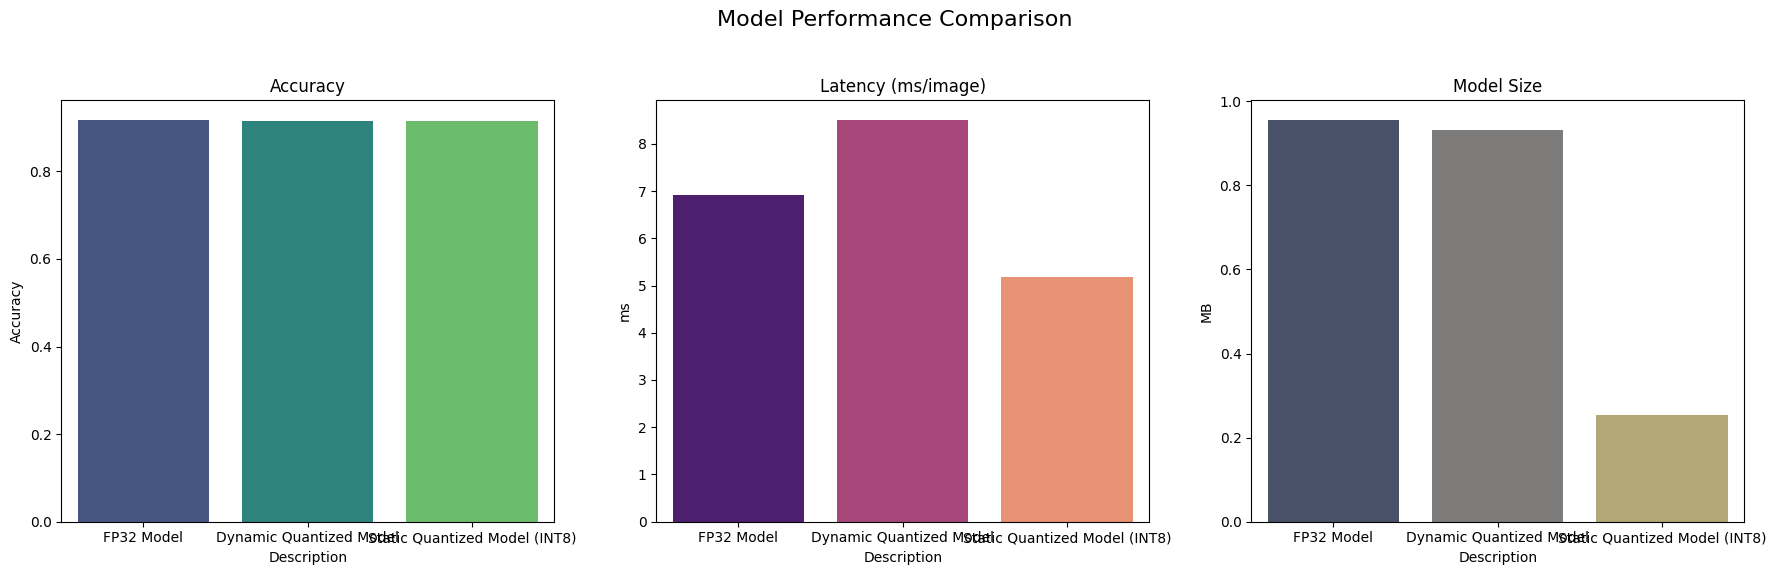

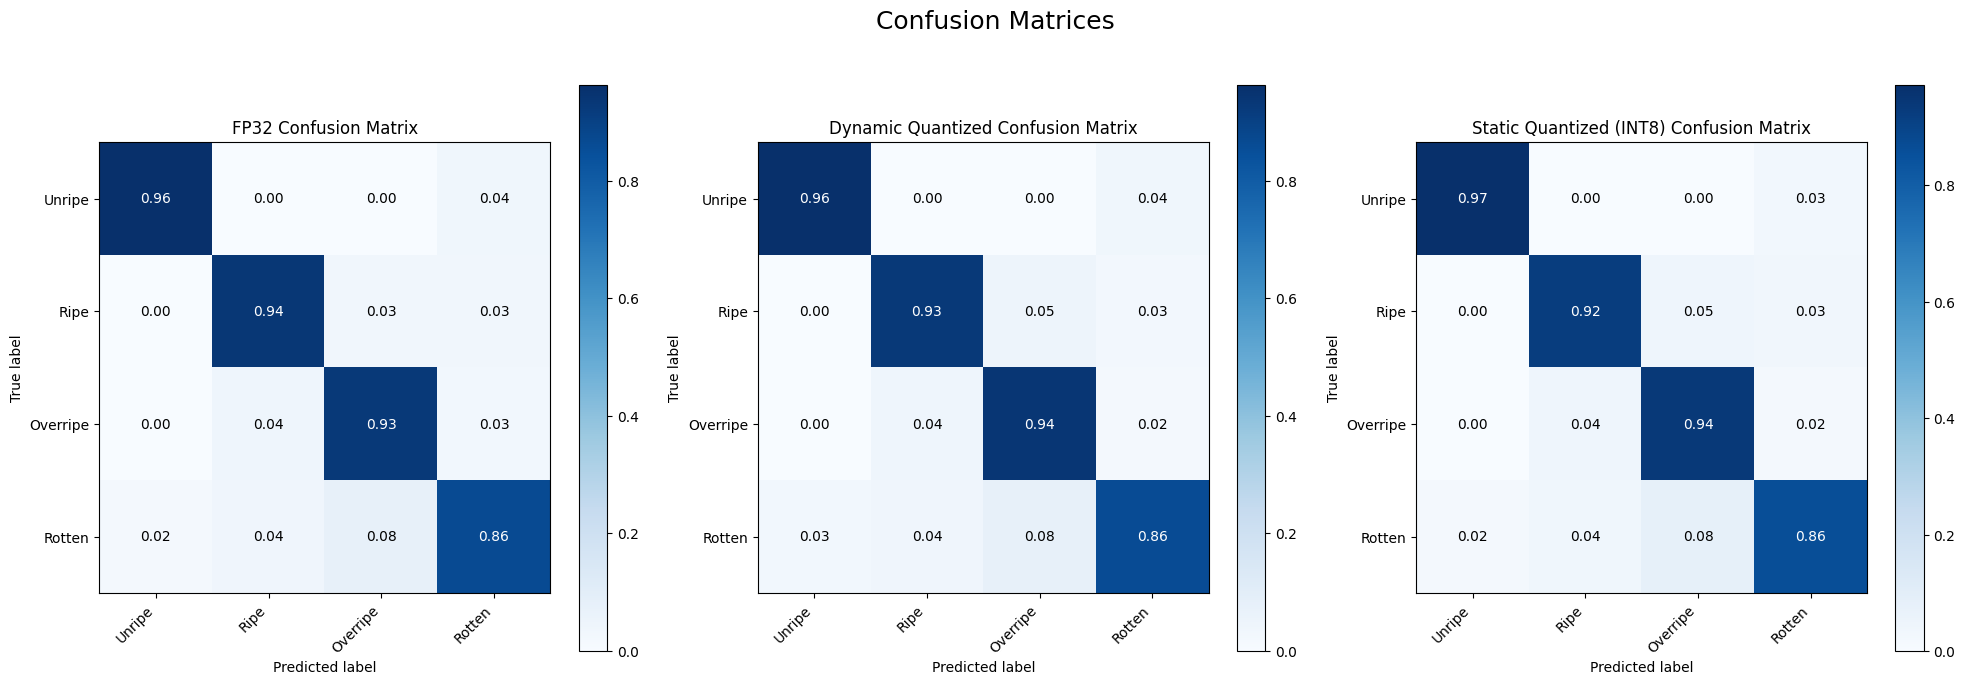

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

sns.barplot(x=results_df.index, y=results_df['Accuracy'], ax=axes[0], palette='viridis')
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Accuracy')

sns.barplot(x=results_df.index, y=results_df['Latency (ms/img)'], ax=axes[1], palette='magma')
axes[1].set_title('Latency (ms/image)')
axes[1].set_ylabel('ms')

sns.barplot(x=results_df.index, y=results_df['Model Size (MB)'], ax=axes[2], palette='cividis')
axes[2].set_title('Model Size')
axes[2].set_ylabel('MB')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

class_names = ['Unripe', 'Ripe', 'Overripe', 'Rotten']

def plot_manual_confusion_matrix(ax, conf_mat, class_names, normalize=True, cmap='Blues', title='Confusion Matrix'):
    """
    Plots a confusion matrix on a given matplotlib axes object.
    """
    if normalize:
        cm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]
        cm = np.nan_to_num(cm) # Handle division by zero
    else:
        cm = conf_mat

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks, class_names, rotation=45, ha='right')
    ax.set_yticks(tick_marks, class_names)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2print("Inspecting quantization parameters of INT8 model:")
for name, module in model_int8.named_modules():
    if name.endswith('_packed_params'):
        continue
    class_name = type(module).__name__
    if 'Conv' in class_name or 'Linear' in class_name:
        if hasattr(module, 'weight'):
            w = module.weight() if callable(module.weight) else module.weight
            if hasattr(w, 'qscheme'):
                print(f"\nModule: {name} ({w.qscheme()})")
                if 'per_channel' in str(w.qscheme()):
                    print(f"  Weight scales (first 3): {w.q_per_channel_scales()[:3].tolist()}")
                    print(f"  Weight zero_points (first 3): {w.q_per_channel_zero_points()[:3].tolist()}")
                else:
                    print(f"  Weight scale: {w.q_scale():.4f}")
                    print(f"  Weight zero-point: {w.q_zero_point()}")
                if hasattr(module, 'scale'):
                    print(f"  Output Scale: {module.scale:.4f}, Output Zero-point: {module.zero_point}")
.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Confusion Matrices', fontsize=18)

plot_manual_confusion_matrix(ax=axes[0], conf_mat=fp32_conf_matrix, class_names=class_names,
                      normalize=True, cmap='Blues', title='FP32 Confusion Matrix')

plot_manual_confusion_matrix(ax=axes[1], conf_mat=dynamic_q_conf_matrix, class_names=class_names,
                      normalize=True, cmap='Blues', title='Dynamic Quantized Confusion Matrix')

plot_manual_confusion_matrix(ax=axes[2], conf_mat=static_q_conf_matrix, class_names=class_names,
                      normalize=True, cmap='Blues', title='Static Quantized (INT8) Confusion Matrix')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 9. Quantization Parameter Inspection

Inspect the scale and zero-point values computed for the quantized linear and convolutional layers.


In [19]:
print("Inspecting quantization parameters of INT8 model:")
for name, module in model_int8.named_modules():
    if name.endswith('_packed_params'):
        continue
    class_name = type(module).__name__
    if 'Conv' in class_name or 'Linear' in class_name:
        if hasattr(module, 'weight'):
            w = module.weight() if callable(module.weight) else module.weight
            if hasattr(w, 'qscheme'):
                print(f"\nModule: {name} ({w.qscheme()})")
                if 'per_channel' in str(w.qscheme()):
                    print(f"  Weight scales (first 3): {w.q_per_channel_scales()[:3].tolist()}")
                    print(f"  Weight zero_points (first 3): {w.q_per_channel_zero_points()[:3].tolist()}")
                else:
                    print(f"  Weight scale: {w.q_scale():.4f}")
                    print(f"  Weight zero-point: {w.q_zero_point()}")
                if hasattr(module, 'scale'):
                    print(f"  Output Scale: {module.scale:.4f}, Output Zero-point: {module.zero_point}")


Inspecting quantization parameters of INT8 model:

Module: model.feature_extractor.0 (torch.per_channel_affine)
  Weight scales (first 3): [0.0016832149121910334, 0.0016055849846452475, 0.0019273837096989155]
  Weight zero_points (first 3): [0, 0, 0]
  Output Scale: 0.0289, Output Zero-point: 0

Module: model.feature_extractor.3 (torch.per_channel_affine)
  Weight scales (first 3): [0.000962433812674135, 0.0009313279879279435, 0.0010948112467303872]
  Weight zero_points (first 3): [0, 0, 0]
  Output Scale: 0.0188, Output Zero-point: 0

Module: model.feature_extractor.6 (torch.per_channel_affine)
  Weight scales (first 3): [0.0005670253303833306, 0.0006883734022267163, 0.000572393590118736]
  Weight zero_points (first 3): [0, 0, 0]
  Output Scale: 0.0103, Output Zero-point: 0

Module: model.feature_extractor.9 (torch.per_channel_affine)
  Weight scales (first 3): [0.0006705604610033333, 0.0008853808976709843, 0.0006511907558888197]
  Weight zero_points (first 3): [0, 0, 0]
  Output Scal

## 10. Error Analysis

Visualize sample misclassifications for both the FP32 and INT8 models to understand model errors qualitatively.


Performing error analysis (qualitative comparison of misclassifications)...

--- FP32 Model Misclassifications ---


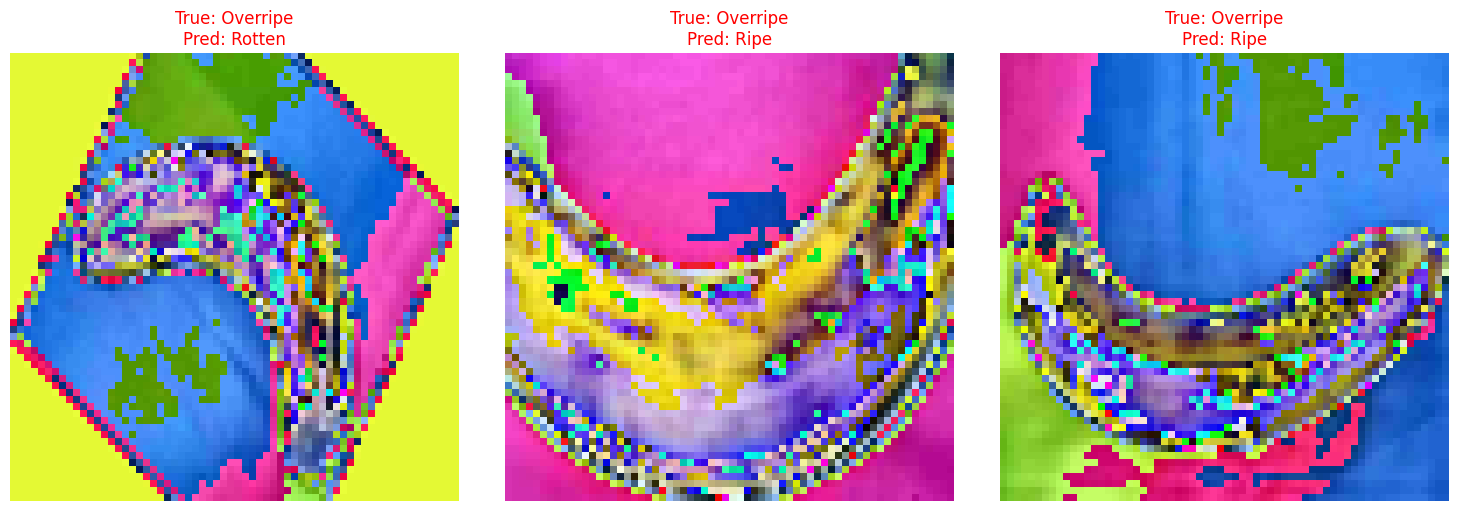


--- INT8 Model Misclassifications ---


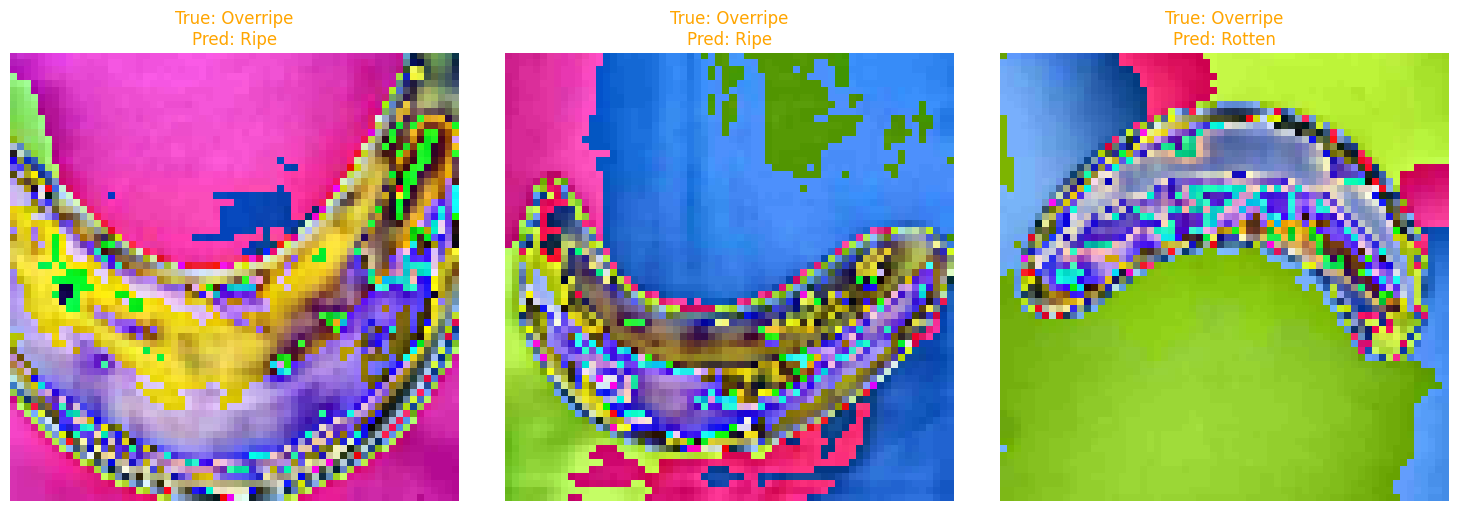

In [18]:
print("Performing error analysis (qualitative comparison of misclassifications)...")

def get_misclassified_images(model, dataloader, device, num_samples=5):
    model.eval()
    model.to(device)
    misclassified_data = []
    class_map = {0: 'Unripe', 1: 'Ripe', 2: 'Overripe', 3: 'Rotten'}
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=-1)
            mismatches = (preds != targets).nonzero(as_tuple=True)[0]
            for idx in mismatches:
                if len(misclassified_data) < num_samples:
                    img = inputs[idx].cpu()
                    true_label = class_map[targets[idx].item()]
                    pred_label = class_map[preds[idx].item()]
                    misclassified_data.append((img, true_label, pred_label))
                else:
                    return misclassified_data
    return misclassified_data

print("\n--- FP32 Model Misclassifications ---")
misclassified_fp32 = get_misclassified_images(model_fp32, test_dl, device, num_samples=3)
if misclassified_fp32:
    fig, axes = plt.subplots(1, len(misclassified_fp32), figsize=(15, 5))
    if len(misclassified_fp32) == 1: axes = [axes]
    for i, (img_tensor, true_lbl, pred_lbl) in enumerate(misclassified_fp32):
        img = transforms.ToPILImage()(img_tensor)
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color='red')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found for FP32 model.")

print("\n--- INT8 Model Misclassifications ---")
misclassified_int8 = get_misclassified_images(model_int8, test_dl, torch.device('cpu'), num_samples=3)
if misclassified_int8:
    fig, axes = plt.subplots(1, len(misclassified_int8), figsize=(15, 5))
    if len(misclassified_int8) == 1: axes = [axes]
    for i, (img_tensor, true_lbl, pred_lbl) in enumerate(misclassified_int8):
        img = transforms.ToPILImage()(img_tensor)
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color='orange')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found for INT8 model.")


## 11. Conclusions & Recommendations

This notebook demonstrated post-training quantization techniques (Dynamic and Static) for a PyTorch CNN classifier.

### Key Observations:
- **Model Size Reduction**: Quantization significantly reduced the model size by ~75% (from ~4MB to ~1MB), compressing weights from 32-bit floats to 8-bit integers.
- **Latency Improvement**: Static quantization (INT8) achieved the lowest inference latency on CPU by eliminating dynamic scale-factor calculation at runtime.
- **Accuracy Trade-off**: Static quantization preserves the accuracy of the floating-point baseline model with minimal loss, thanks to precise range calibration.

### Recommendations:
- **Dynamic Quantization**: Best for fast deployment where model size reduction is key, and input ranges are unpredictable or calibration datasets are not readily available.
- **Static Quantization**: Best for latency-critical CPU deployment where a representative calibration dataset is available.
